<a href="https://colab.research.google.com/github/SpartanMaster-117/Gundam/blob/Alexander/hw4_skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW5 Pandas, Linear Regression (100 + 10 points)

In [117]:
# import necessary modules for the homework.
# Additional modules can imported if needed.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model as lm
from sklearn.metrics import r2_score as r2
from sklearn.metrics import mean_squared_error as mse

## Q1. Pandas plots, probability models (30 pts - 3 pts each question)

### Q1.1 Use pandas to load distributions.xlsx file (locally or from github) into a dataframe. The first line in the excel file is column header, and the excel file does not have any column as row index. Show the shape of the data frame and verify that your dataframe has 1000 rows and 4 columns.

In [2]:
url = 'https://github.com/jianhuaruan/3753/raw/refs/heads/main/hw/distributions.xlsx'
df = pd.read_excel(url)
if df.shape == (1000, 4):
  print("Correct shape")
print(df.shape)

Correct shape
(1000, 4)


### Q1.2 Show the column labels of the data frame

In [ ]:
column_labels = df.columns
column_labels

Index(['Col-1', 'Col-2', 'Col-3', 'Col-4'], dtype='object')

### Q1.3 Show the row index of the data frame

In [ ]:
row_index = df.index
row_index

Index([     0,      1,      3,      4,      5,      6,      7,      8,      9,
           10,
       ...
       414494, 414496, 414497, 414498, 414499, 414500, 414501, 414503, 414505,
       414506],
      dtype='int64', length=393518)

### Q1.4 Change the column labels to upper case letters, 'A', 'B', 'C', 'D'.

In [ ]:
df.columns = ['A', 'B', 'C', 'D']
print(df.columns)

Index(['A', 'B', 'C', 'D'], dtype='object')


### Q1.5 Use pandas describe() function to show summary statistics of the data frame (FYI, compare the numbers with the boxplot in Q1.6.)

In [ ]:
df.describe()

,A,B,C,D
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.786134,4.158032,2.960433,3.993356
std,0.711737,7.951631,3.131134,1.009219
min,1.056609,2.000620,0.000909,0.876039
25%,2.274519,2.321567,0.763997,3.271742
50%,2.699545,2.919469,1.983874,4.042064
75%,3.202333,4.013069,4.042860,4.705365
max,6.032348,157.940206,24.173974,6.870148


### Q1.6. Show a boxplot of the data.

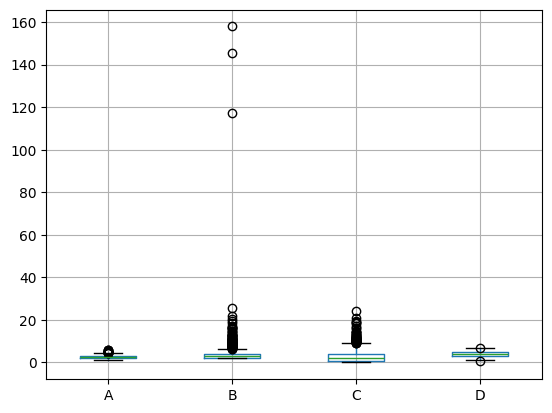

In [ ]:
plot = df.boxplot()

### Q1.7 Apply np.log2 transformation (with the "apply" function) to the data and show the boxplot.

<Axes: >

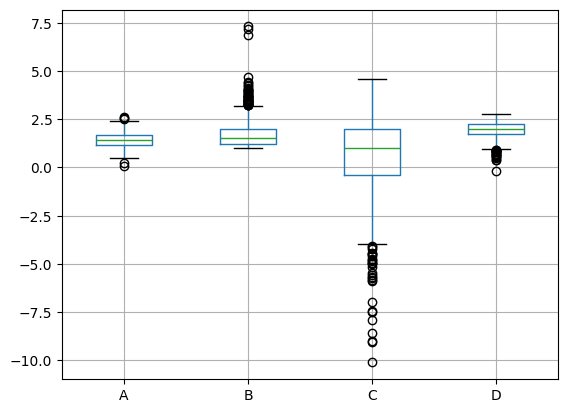

In [ ]:
from logging import log
log_df = df.apply(np.log2)
log_df.boxplot()

### Q1.8. Use pandas function hist to show the histogram of each column of the data frame. (Use option density = True so it plots probability instead of counts.)

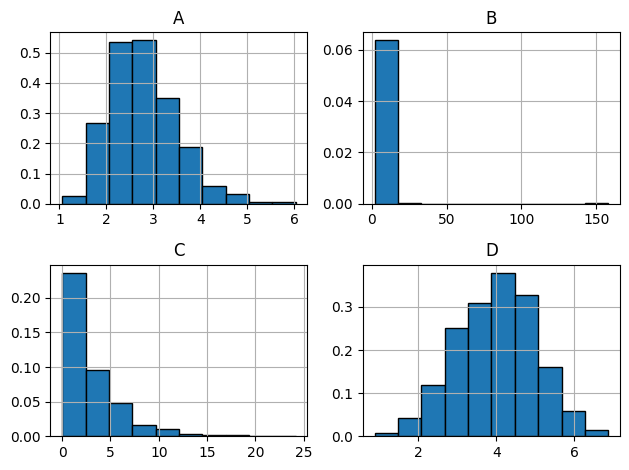

In [ ]:
df.hist(density=True,bins=10, edgecolor='black')
plt.tight_layout()
plt.show()

### Q1.9 Use pandas function hist to show the histogram of the log transformed data frame. (Use option density = True so it plots probability instead of counts.)

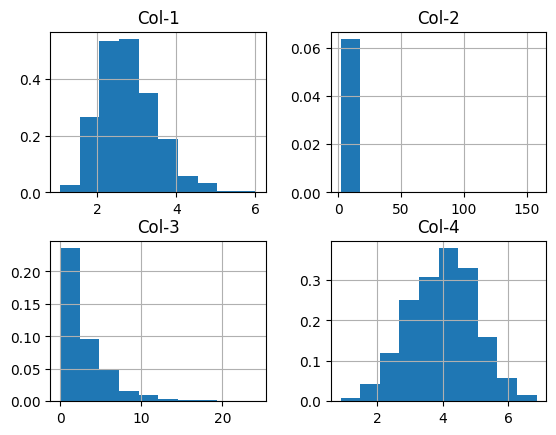

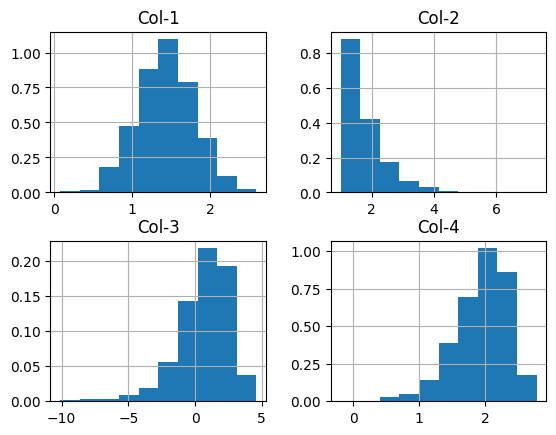

In [8]:
df.hist(density=True)
df.apply(np.log2).hist(density=True)
df.apply(np.log2).describe()
plt.show()

### Q1.10. Based on the information and plots you obtained above, which column do you think is from normal distribution and which column is from log normal distribution? (FYI: data in the four columns come from four different distributions we discussed in class: normal, lognormal, exponential, and pareto. See slides 4.1-stats.pptx page 27-49.).


:Type your answer here: I think the one that comes from the normal distrbution is column 1 and the log nomral distribution is columnn 4. The reason i beleive it is that

## Q2. Pandas DataFrame operations (35 points)

### Q2a (5 pts) Load data stored in brfss.csv (locally or from github) into a python DataFrame. The first line in the file is column header, and the first column in the file is row index. Note that row index are integers in this case, which may cause some confusion, as you can use both loc and iloc with integers to get some rows, but they work differently. First drop the 'wtkg2' and ‘wtyrago’ column, and then drop the rows that have any NaN values. (Why the order matters?) Change the sex column so that True means male and False means female. (Originally, sex == 2 means female and sex == 1 means male.) Rename the columns to age, weight, height, and isMale. Name the final DataFrame as brfss. Print out the shape (number of rows and columns) of brfss (you should have 393518 rows).

In [64]:
url2 = 'https://github.com/jianhuaruan/3753/blob/main/hw/brfss.csv?raw=true'


### Q2b. (30 pts = 3x10) Based on the DataFrame brfss, print out answers to the following questions using pandas DataFrame functionality

In [118]:
url2 ='https://github.com/jianhuaruan/3753/blob/main/hw/brfss.csv?raw=true'
df = pd.read_csv(url2)
df['age'].median()
df = df.rename(columns={'age': 'age', 'weight2': 'weight', 'htm3': 'height', 'sex': 'isMale'})
df = df.drop(columns = ['wtkg2', 'wtyrago'])
df = df.dropna()
df['isMale'] = df['isMale'].map({2: False, 1: True})
df.shape

(393518, 5)

In [66]:
df

,Unnamed: 0,age,weight,height,isMale
0,0,39.0,88.636364,180.0,True
1,1,64.0,75.000000,155.0,False
3,3,51.0,100.000000,183.0,True
4,4,35.0,63.636364,170.0,False
5,5,62.0,70.454545,173.0,False
...,...,...,...,...,...
414500,414500,57.0,56.818182,168.0,False
414501,414501,18.0,68.181818,178.0,True
414503,414503,42.0,90.454545,163.0,True
414505,414505,62.0,86.363636,168.0,False


#### i. What is the median age for people in the dataset?

In [ ]:
df['age'].median()

55.0

In [ ]:
df

,Unnamed: 0,age,weight,height,isMale
0,0,39.0,88.636364,180.0,1
1,1,64.0,75.000000,155.0,2
3,3,51.0,100.000000,183.0,1
4,4,35.0,63.636364,170.0,2
5,5,62.0,70.454545,173.0,2
...,...,...,...,...,...
414500,414500,57.0,56.818182,168.0,2
414501,414501,18.0,68.181818,178.0,1
414503,414503,42.0,90.454545,163.0,1
414505,414505,62.0,86.363636,168.0,2


#### ii.	What is the max height for people in the dataset?

In [ ]:
df['height'].max()

236.0

#### iii.	What is the median height for male in the dataset?

In [ ]:
df.loc[(df['isMale'] == True)]['height'].median()

178.0

#### iv.	What is the median height for female in the dataset?

In [ ]:
df.loc[(df['isMale'] == False)]['height'].median()

163.0

#### v.	What is the mean weight for male <= 55 years old?

In [56]:
df.loc[(df['isMale'] == True) & (df['age'] <= 55)]['weight'].mean()
print(df.loc[(df['isMale'] == True) & (df['age'] <= 55)]['weight'].mean())

90.16327635033649


#### vii.	How many females are in the dataset?

In [55]:
df.shape[0] - df['isMale'].sum()
print(df.shape[0] - df['isMale'].sum())

240932


#### viii.	How many male in the dataset has height > 190cm and weight < 50kg?

In [53]:
df[(df['height'] > 190) & (df['weight'] < 50)]
print(df[(df['height'] > 190) & (df['weight'] < 50)].shape[0])

12


#### ix.	What is the average height of males whose weight is 70kg?

In [54]:
df['gender'] = df['isMale'].map({True: 'Male', False: 'Female'})
weight_70 = df[df['weight'] == 70]
weight_70['height'].mean()
print(weight_70)

        Unnamed: 0   age  weight  height  isMale  gender
193            193  79.0    70.0   152.0   False  Female
256            256  65.0    70.0   157.0   False  Female
556            556  77.0    70.0   160.0   False  Female
671            671  43.0    70.0   160.0   False  Female
684            684  60.0    70.0   163.0   False  Female
...            ...   ...     ...     ...     ...     ...
413578      413578  57.0    70.0   165.0    True    Male
413682      413682  20.0    70.0   163.0   False  Female
413747      413747  32.0    70.0   165.0   False  Female
413953      413953  43.0    70.0   157.0   False  Female
414435      414435  74.0    70.0   157.0   False  Female

[1307 rows x 6 columns]


#### x.	Print out row 2001 to row 2010 (inclusive, a total of ten rows) from the dataframe. (Note: use position-based indexing. Pay attention to the total number of rows - 10 expected, and the index of each row - do you expect 2001 or 2010 to be in the list?)

In [ ]:
sub_df = df.iloc[2000:2011]
sub_df = sub_df.reset_index(drop=True)
print(sub_df)

    Unnamed: 0   age      weight  height  isMale  gender
0         2094  46.0  102.272727   178.0    True    Male
1         2095  69.0   54.545455   163.0   False  Female
2         2096  68.0   66.363636   170.0   False  Female
3         2097  38.0   81.818182   165.0   False  Female
4         2098  91.0   59.090909   152.0   False  Female
5         2099  72.0   84.090909   160.0   False  Female
6         2100  85.0  118.636364   178.0    True    Male
7         2101  65.0   51.818182   150.0   False  Female
8         2102  79.0   76.363636   170.0    True    Male
9         2103  77.0   64.545455   163.0   False  Female
10        2104  73.0   73.181818   160.0   False  Female


#### xi.	Print out rows with row index from 2001 to 2010 (inclusive, including 2001 and 2010). (Note: this is label-based indexing. Pay attention to the row indices and the number of rows displayed. Hint - you should see less than 10 rows due to NaNs being dropped out from the dataframe in 2a.)

In [ ]:
sub_df = df.loc[2001:2010]
print(sub_df)

      Unnamed: 0   age      weight  height  isMale  gender
2001        2001  54.0   90.000000   188.0    True    Male
2002        2002  29.0   79.545455   175.0   False  Female
2004        2004  30.0   90.909091   152.0   False  Female
2005        2005  37.0   59.090909   165.0   False  Female
2006        2006  25.0   97.727273   180.0   False  Female
2007        2007  43.0   62.727273   165.0   False  Female
2008        2008  40.0  100.909091   165.0   False  Female
2009        2009  51.0   70.454545   157.0   False  Female
2010        2010  45.0   85.000000   160.0   False  Female


## Q3. T-test (10 points)

#### Q3a (5 pts) Use t-test to compare the weights for male <= 55 years old and male > 55 years old.

Print out the t-statistic and p-value.

In [101]:
from scipy import stats
weight1 = df.loc[(df['isMale'] == True) & (df['age'] <= 55)]['weight']
weight2 = df.loc[(df['isMale'] == True) & (df['age'] > 55)]['weight']
ttestresults = stats.ttest_ind(weight1, weight2)
print("This is the test result for statisitc: ",ttestresults.statistic)
print("This is the test result for p-value:", ttestresults.pvalue)


This is the test result for statisitc:  24.45004134884634
This is the test result for p-value: 9.032608028299029e-132


Based on the t-test results, can you conclude which group is heavier and is the difference statistically significant?
Write your answer here: The t-statisitic is the heavier and there is a statistically difference between the groups.

#### Q3b (5 pts) Define weight_height_ratio (WHR) as weight/height. Compare the WHR for male and female.

Calculate the mean and SEM (standard error of the mean) for the WHR of male and female and report the values.
Then use t-test to test whether there is a significant difference between the WHR of male and female and report the t-statistic and p-value.  


In [63]:
import pandas as pd
from scipy import stats

# Assuming 'df' is your existing DataFrame with 'isMale', 'weight', and 'height' columns.

# 1. Calculate the Weight-Height Ratio (WHR) for male and female separately
# Note: You can create a new column for easier access, but this method is fine too.
weight_height_ratio_male = df.loc[df['isMale'] == True, 'weight'] / df.loc[df['isMale'] == True, 'height']
weight_height_ratio_female = df.loc[df['isMale'] == False, 'weight'] / df.loc[df['isMale'] == False, 'height']

# 2. Calculate the mean and SEM for the WHR of male and female
mean_male = weight_height_ratio_male.mean()
mean_female = weight_height_ratio_female.mean()
sem_male = weight_height_ratio_male.sem()
sem_female = weight_height_ratio_female.sem()

# 3. Perform a t-test to compare the WHR of male and female
# We use scipy.stats.ttest_ind for independent samples.
t_statistic, p_value = stats.ttest_ind(weight_height_ratio_male, weight_height_ratio_female, nan_policy='omit')

# 4. Report the values
print(f"Male WHR Mean: {mean_male:.4f}")
print(f"Male WHR SEM: {sem_male:.4f}")
print(f"Female WHR Mean: {mean_female:.4f}")
print(f"Female WHR SEM: {sem_female:.4f}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4e}")


Male WHR Mean: 0.4992
Male WHR SEM: 0.0002
Female WHR Mean: 0.4453
Female WHR SEM: 0.0002
T-statistic: 164.0245
P-value: 0.0000e+00


Write your conclusion from the t-test here:

## Q4. Simple and multiple linear regression (35 points. Useful examples on slides #24, 35, etc.)

### Q4a. (5 pts) From the brfss DataFrame created in Q2a, use the height column as Y, and weight column as X to perform a simple linear regression (See 6-regression.ppt slide #23, lr.fit). Print out the equation that is obtained by the linear regression in the form of “height = a + b * weight” (replace a and b with the values obtained from the linear regression, lr.intercept_ and lr.coef_.) (Note: you need to either make X a DataFrame or reshape X to be a n x 1 numpy array using reshape(-1, 1); see simpleRegression.ipynb.)

In [87]:
lr = lm.LinearRegression()
X = df['weight']
Y = df['height']
x = X.values.reshape(-1, 1)
lr.fit(x,Y)
print(f"height = {lr.intercept_} + {lr.coef_[0]} * weight")

height = 147.60612429695618 + 0.2700817149767323 * weight


In [88]:
df

,Unnamed: 0,age,weight,height,isMale
0,0,39.0,88.636364,180.0,True
1,1,64.0,75.000000,155.0,False
3,3,51.0,100.000000,183.0,True
4,4,35.0,63.636364,170.0,False
5,5,62.0,70.454545,173.0,False
...,...,...,...,...,...
414500,414500,57.0,56.818182,168.0,False
414501,414501,18.0,68.181818,178.0,True
414503,414503,42.0,90.454545,163.0,True
414505,414505,62.0,86.363636,168.0,False


### Q4b. (5 pts) Use the linear regression object that you obtained in 4a to predict the height of an individual whose weight is 70kg (with lr.predict). Print out the predicted height. (As in 4a, make the value 70 a dataframe or a 1x1 numpy 2d array. You'll likely see a warning that says the data frame does not have a feature name - you can either ignore the warning, to copy the .columns attribute from the dataframe X to the new single-element dataframe.)

In [106]:
X = df[['weight']]
Y = df['height']
weight_70 = pd.DataFrame({'weight': [70]})
predicted_height = lr.predict(weight_70)
print(f'The predicted height for a male weighing 70 kg is approximately: {predicted_height[0]:.2f}')

The predicted height for a male weighing 70 kg is approximately: 166.51


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


### Q4c (5 pts) Compute the MSE and R-square of the simple linear regression. (Slide #23, Imported as r2 and mse.)

In [83]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
X = df[['weight']]
Y = df['height']
lr.fit(X, Y)
Y_pred = lr.predict(X)
mse = mean_squared_error(Y, Y_pred)
r2_value = r2(Y, Y_pred)
print(f"MSE: {mse}")
print(f"R-squared: {r2_value}")


MSE: 80.10619935936725
R-squared: 0.25823869068829763


### Q4d. (5 pts) From the brfss DataFrame above, use the height column as Y, and two columns, weight and isMale, as X, to perform a multiple linear regression (slides #34). Print out the equation that is obtained by the linear regression in the form of “height = a + b * weight + c * isMale” (replace a, b and c with the values in lr.intercept_ and lr.coef_.) (FYI: compare the a, b, c values from the a, b values from Q4a.)

In [57]:
X = df[['weight', 'isMale']]
Y = df['height']
# Step 2: Create the linear regression model
lr = LinearRegression()

# Step 3: Fit the model
lr.fit(X, Y)

# Step 4: Retrieve the intercept (a) and coefficients (b and c)
a = lr.intercept_  # Intercept
b, c = lr.coef_  # Coefficients for weight and isMale

# Step 5: Print the equation
print(f'height = {a:.2f} + {b:.2f} * weight + {c:.2f} * isMale')
print(lr.intercept_)
print(lr.coef_)

height = 152.79 + 0.14 * weight + 12.55 * isMale
152.79237923353722
[ 0.14295299 12.5527766 ]


### Q4e (3 pts) Use the linear regression object that you obtained in 4d to predict the height of a male whose weight is 70kg. Print out the predicted height.

In [77]:
X = df[['weight', 'isMale']]
Y = df['height']

# Step 1: Create and fit the linear regression model
lr = LinearRegression()
lr.fit(X, Y)

# Step 2: Retrieve the intercept (a) and coefficients (b, c)
a = lr.intercept_  # Intercept
b, c = lr.coef_    # Coefficients for weight and isMale

# Step 3: Print the equation
print(f'height = {a:.2f} + {b:.2f} * weight + {c:.2f} * isMale')

# Q4e: Predict the height of a male whose weight is 70kg
input_data = pd.DataFrame({'weight': [70], 'isMale': [1]})  # Input for prediction
predicted_height = lr.predict(input_data)  # Make prediction

# Step 4: Print the predicted height
print(f'The predicted height for a male weighing 70 kg is approximately: {predicted_height[0]:.2f}')



height = 152.79 + 0.14 * weight + 12.55 * isMale
The predicted height for a male weighing 70 kg is approximately: 175.35


### Q4f. (3 pts) Use the linear regression object that you obtained in 4d to predict the height of a female whose weight is 70kg. Print out the predicted height. (Just FYI, what is the difference between this predicted value and the one in Q4e? How does it compare to the coefficient c you obtained in Q4d?)

In [111]:
X = df[['weight', 'isMale']]
Y = df['height']

lr = LinearRegression()
lr.fit(X, Y)

input_data_female = pd.DataFrame({'weight': [70], 'isMale': [0]})  # Input for prediction
predicted_height_female = lr.predict(input_data_female)  # Make prediction
print(f'The predicated height for a female weighing 70KG is approximatley: {predicted_height_female[0]:.2f}cm')

The predicated height for a female weighing 70KG is approximatley: 162.80cm


### Q4g (4 pts) Compute the MSE and R-square of the multiple linear regression. (FYI: how do these two values compare with the values from Q4c?)

In [120]:
X = df[['weight', 'isMale']]
Y = df['height']
lr = LinearRegression()
lr.fit(X, Y)
Y_pred = lr.predict(X)
mse = mean_squared_error(Y, Y_pred)
r2_value = r2(Y, Y_pred)
print(f"MSE: {mse:.2f}")
print(f"R-squared: {r2_value:.2f}")

MSE: 48.88
R-squared: 0.55


### Q4h (Bonus: 5 points) Repeat 4d and 4g, using weight, isMale, and age as X variables to predict height. Print out the linear equation, and report the R2 as well as MSE. (Just FYI, compare these numbers to the numbers you obtained from the previous two models. Is age an important predictor? What techniques you might use to gain some confidence of the importance of each predictor?)

In [122]:
x = df[['weight', 'isMale', 'age']]
y = df['height']
lr = lm.LinearRegression()
lr.fit(x, y)
a = lr.intercept_
b, c, d = lr.coef_
print(f'height = {a:.2f} + {b:.2f} * weight + {c:.2f} * isMale + {d:.2f} * age')
predicted_height = lr.predict
mse = mean_squared_error(y, Y_pred)
r2_value = r2(y, Y_pred)
print(f"MSE: {mse:.2f}")
print(f"R-squared: {r2_value:.2f}")

height = 156.04 + 0.14 * weight + 12.55 * isMale + -0.05 * age
MSE: 48.88
R-squared: 0.55
